### Import Libraries

In [27]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

# Plot settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Create folder to save plots
os.makedirs("../visualizations", exist_ok=True)

### Load Dataset

In [28]:
df = pd.read_csv("../data/traffic_dataset.csv")
df.head()

,timestamp,hour,day_of_week,geohash_location,road_type,num_lanes,traffic_signals,large_vehicles_count,temperature,humidity,rainfall,weather_conditions,nearby_landmarks,event_indicator,traffic_demand
0,2023-01-01 00:00:00,0,6,gc38,Residential,3,1,4,17.011491,51.704181,0.0,Clear,Hospital,NaN,201
1,2023-01-01 00:05:00,0,6,gc28,Arterial,5,0,10,16.899013,62.508017,0.0,Clear,NaN,Festival,965
2,2023-01-01 00:10:00,0,6,gc14,Local Street,3,0,9,16.375849,49.907796,0.0,Clear,NaN,NaN,322
3,2023-01-01 00:15:00,0,6,gc42,Local Street,4,1,10,11.864347,58.899631,0.0,Clear,Train Station,NaN,419
4,2023-01-01 00:20:00,0,6,gc07,Arterial,4,1,6,15.903433,41.627446,0.0,Clear,Airport,NaN,448


### Basic Dataset Information

In [30]:
print("Dataset Shape")
print(df.shape)
print("\n")
print("Data Types")
print(df.dtypes)
print("\n")
print("Summary Statistics")
print(df.describe(include="all"))

Dataset Shape
(120000, 15)


Data Types
timestamp                   str
hour                      int64
day_of_week               int64
geohash_location            str
road_type                   str
num_lanes                 int64
traffic_signals           int64
large_vehicles_count      int64
temperature             float64
humidity                float64
rainfall                float64
weather_conditions          str
nearby_landmarks            str
event_indicator             str
traffic_demand            int64
dtype: object


Summary Statistics
                  timestamp          hour    day_of_week geohash_location  \
count                120000  120000.00000  120000.000000           120000   
unique               120000           NaN            NaN               50   
top     2023-01-01 00:00:00           NaN            NaN             gc29   
freq                      1           NaN            NaN             2494   
mean                    NaN      11.49360       2.993600    

### Missing Values

In [31]:
print(df.isnull().sum())

timestamp                    0
hour                         0
day_of_week                  0
geohash_location             0
road_type                    0
num_lanes                    0
traffic_signals              0
large_vehicles_count         0
temperature                  0
humidity                     0
rainfall                     0
weather_conditions           0
nearby_landmarks         29994
event_indicator         113985
traffic_demand               0
dtype: int64


### Missing Value Heatmap

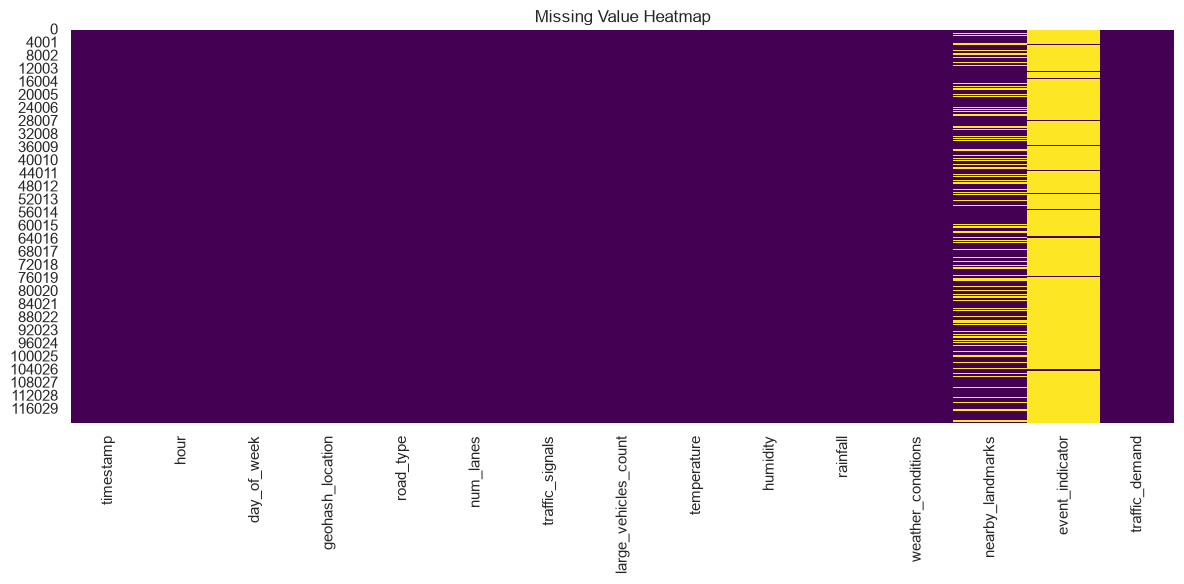

In [32]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.tight_layout()

plt.savefig("../visualizations/05_missing_value_heatmap.png", dpi=300)

plt.show()

### Missing Value Bar Chart

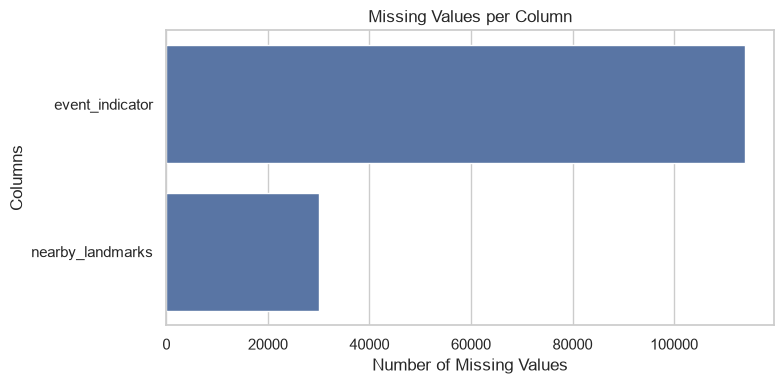

In [33]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title("Missing Values per Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Columns")

plt.tight_layout()


plt.show()

### Separate Numerical Columns

In [34]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['hour', 'day_of_week', 'num_lanes', 'traffic_signals',
       'large_vehicles_count', 'temperature', 'humidity', 'rainfall',
       'traffic_demand'],
      dtype='str')


### Outlier Detection Using IQR

In [35]:
print("Outliers using IQR Method\n")

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outliers using IQR Method

hour: 0 outliers
day_of_week: 0 outliers
num_lanes: 0 outliers
traffic_signals: 0 outliers
large_vehicles_count: 450 outliers
temperature: 0 outliers
humidity: 0 outliers
rainfall: 18000 outliers
traffic_demand: 3938 outliers


### Outlier Detection Using Z-Score

In [36]:
print("Outliers using Z-Score\n")

z_scores = np.abs(zscore(df[numerical_columns]))

for i, col in enumerate(numerical_columns):

    outliers = (z_scores[:, i] > 3).sum()

    print(f"{col}: {outliers} outliers")

Outliers using Z-Score

hour: 0 outliers
day_of_week: 0 outliers
num_lanes: 0 outliers
traffic_signals: 0 outliers
large_vehicles_count: 450 outliers
temperature: 0 outliers
humidity: 0 outliers
rainfall: 3772 outliers
traffic_demand: 1682 outliers


### Boxplots Of Numerical Columns

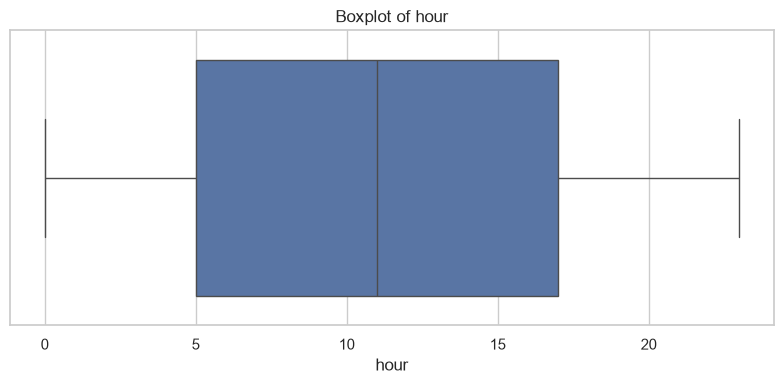

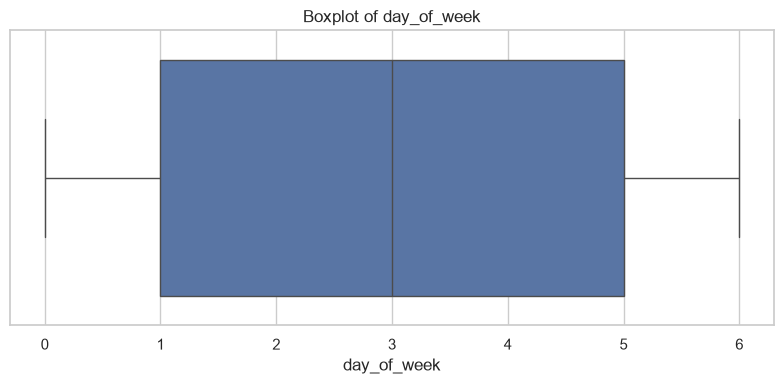

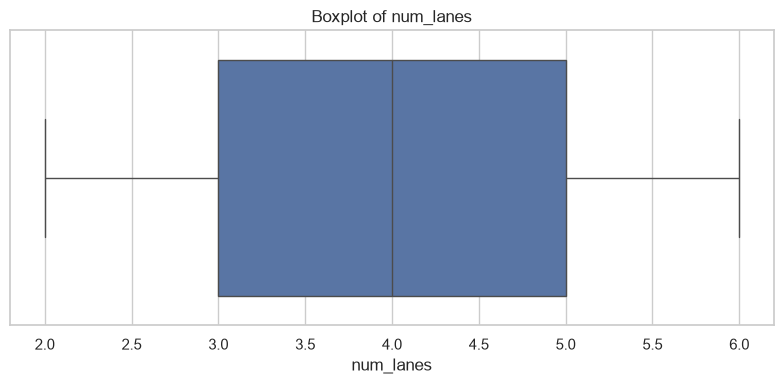

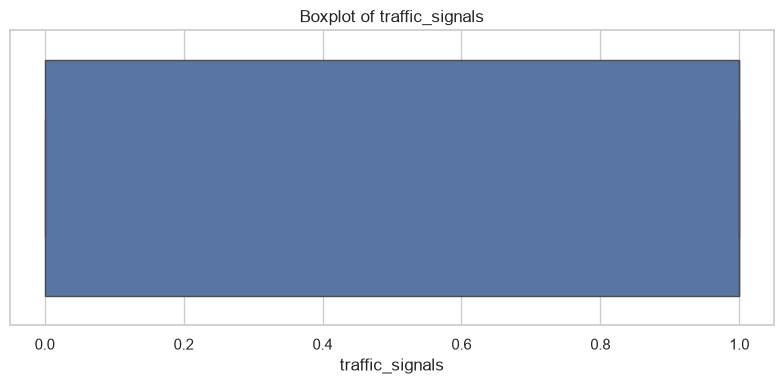

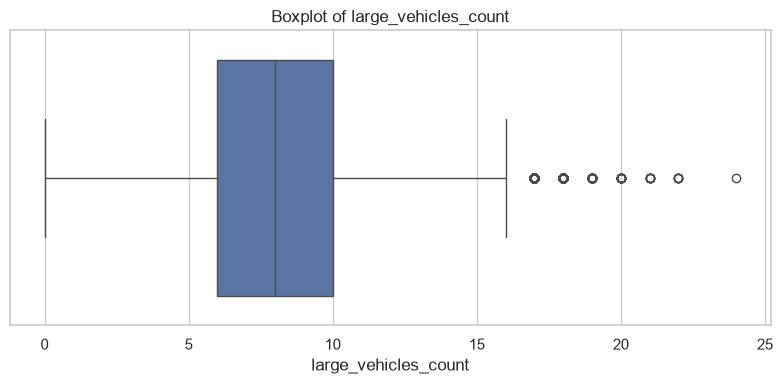

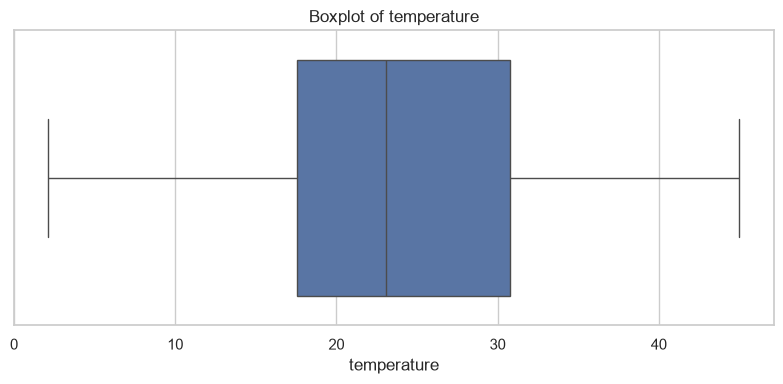

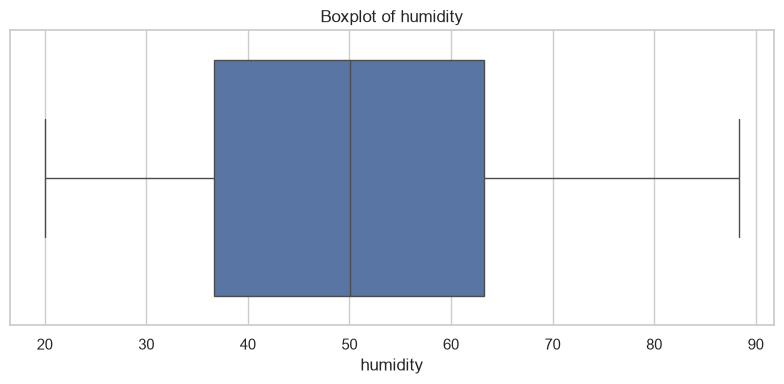

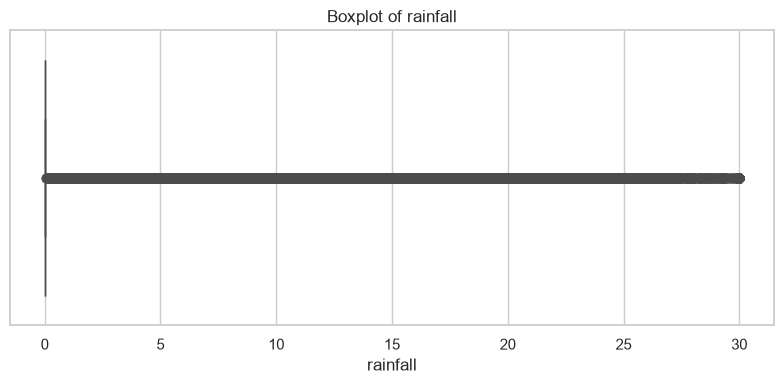

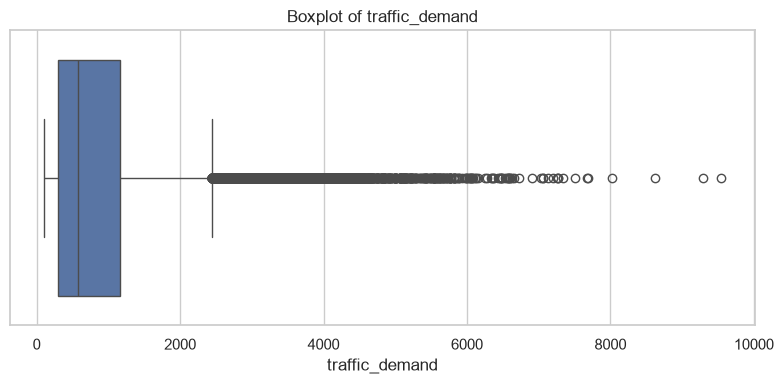

In [37]:
for col in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()


    plt.show()

### Correlation Matrix

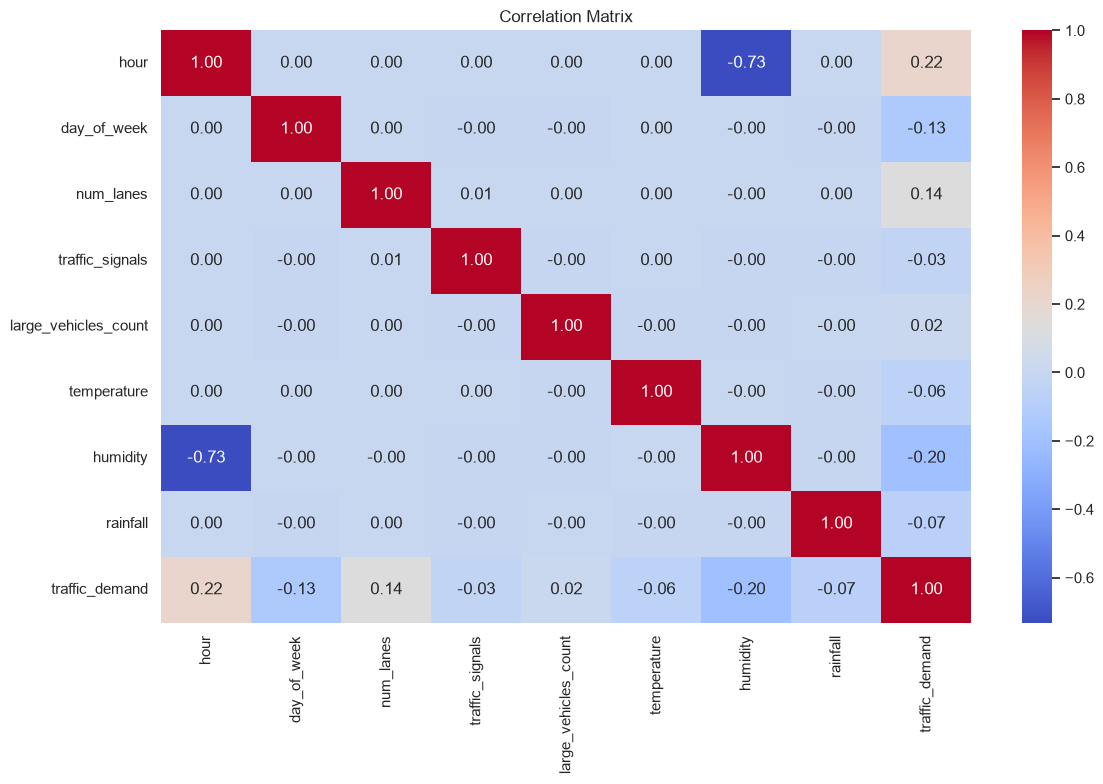

In [38]:
corr = df[numerical_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()


plt.show()

### Traffic Demand Distribution

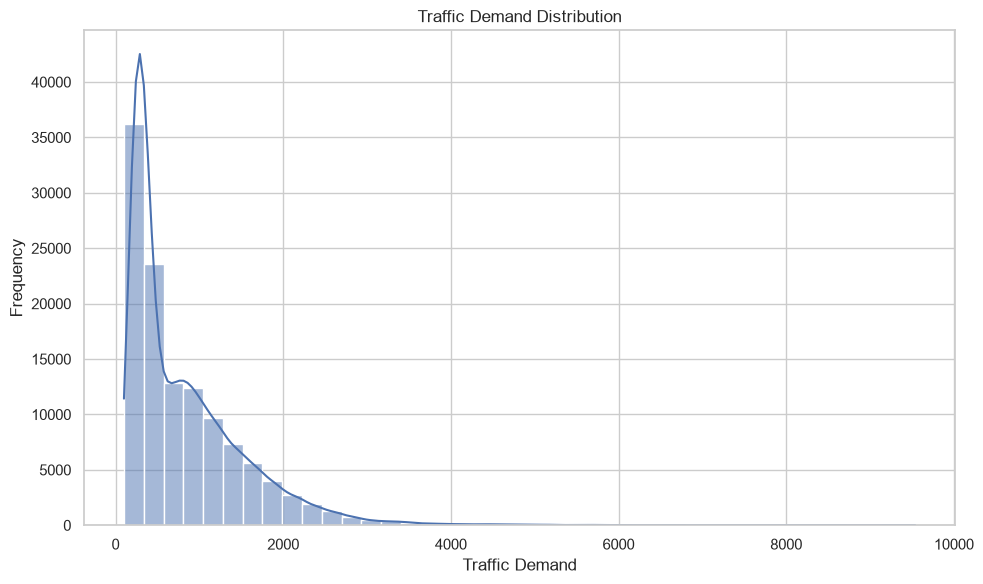

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["traffic_demand"],
    bins=40,
    kde=True
)

plt.title("Traffic Demand Distribution")

plt.xlabel("Traffic Demand")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/01_traffic_demand_distribution.png", dpi=300)

plt.show()

### Create Weekday/Weekend Feature

In [40]:
weekday_list = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

df["day_type"] = np.where(
    df["day_of_week"] < 5,
    "Weekday",
    "Weekend"
)

df[["day_of_week","day_type"]].head()

,day_of_week,day_type
0,6,Weekend
1,6,Weekend
2,6,Weekend
3,6,Weekend
4,6,Weekend


### Hourly Traffic Pattern (Weekday vs Weekend)

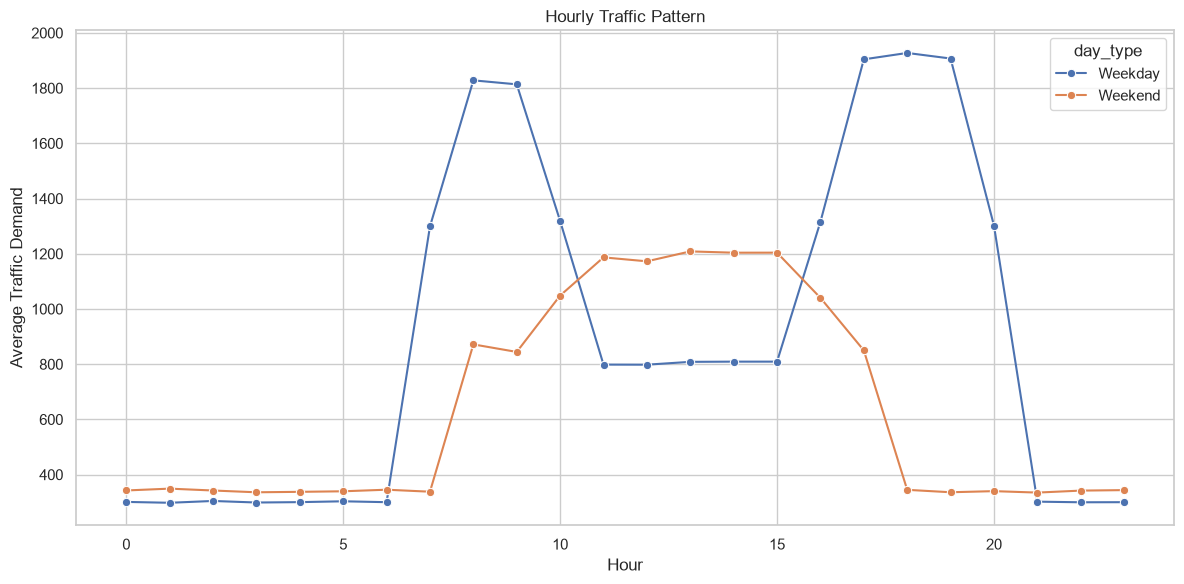

In [41]:
hourly = (
    df.groupby(["day_type", "hour"])["traffic_demand"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly,
    x="hour",
    y="traffic_demand",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Traffic Pattern")

plt.xlabel("Hour")

plt.ylabel("Average Traffic Demand")

plt.tight_layout()

plt.savefig("../visualizations/02_hourly_traffic_pattern.png", dpi=300)

plt.show()

### Road Type vs Traffic Demand

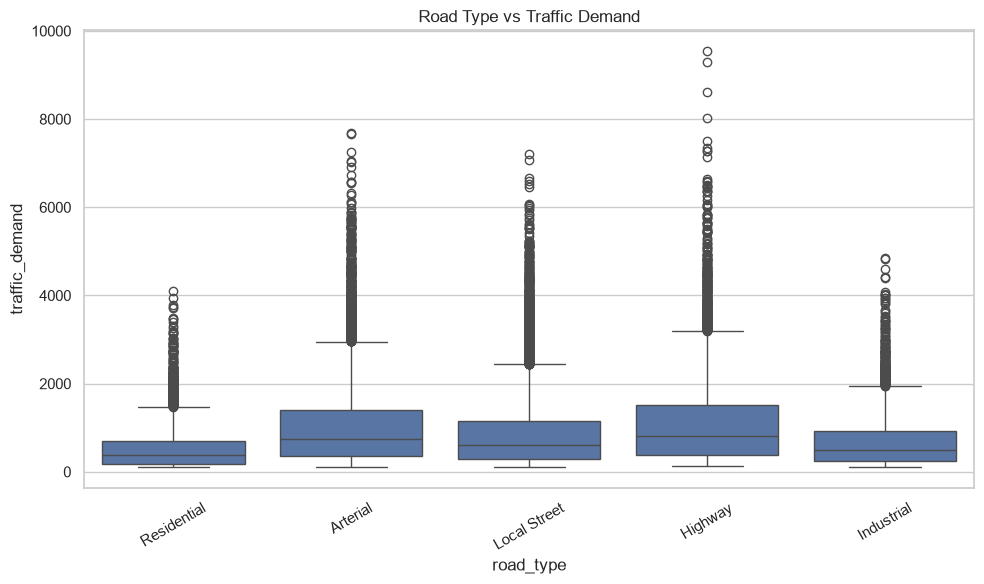

In [42]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="road_type",
    y="traffic_demand"
)

plt.title("Road Type vs Traffic Demand")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("../visualizations/04_road_type_vs_traffic_boxplot.png", dpi=300)

plt.show()

### Weather Impact Analysis

<Figure size 1000x600 with 0 Axes>

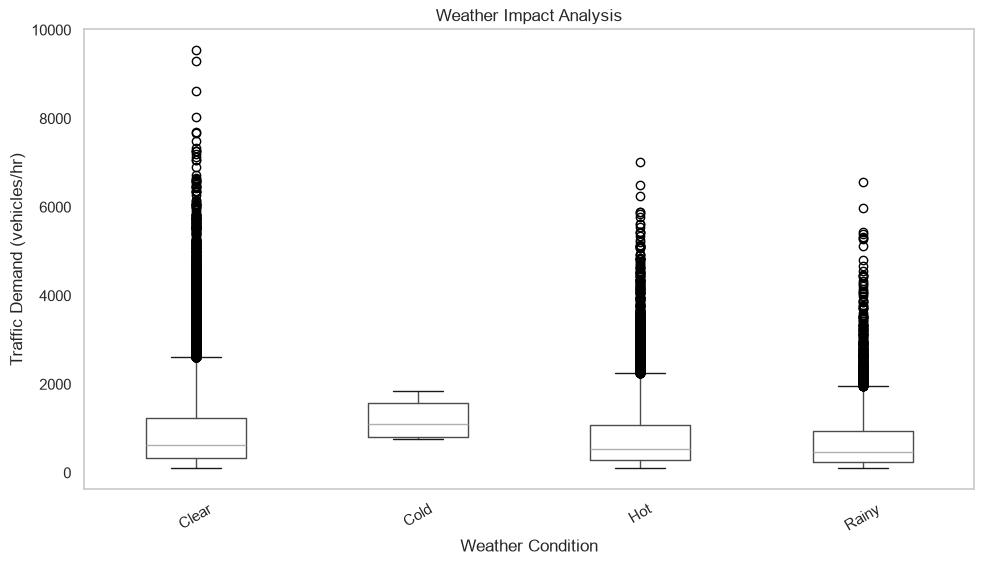

In [43]:
plt.figure(figsize=(10,6))

df.boxplot(
    column="traffic_demand",
    by="weather_conditions",
    grid=False
)

plt.title("Weather Impact Analysis")
plt.suptitle("") 
plt.xlabel("Weather Condition")
plt.ylabel("Traffic Demand (vehicles/hr)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../visualizations/03_weather_impact_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()